In [1]:
from pathlib import Path
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm import tqdm

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
EX35_DIR = PROJECT_ROOT / "data" / "exercise_3_5"

TRAIN_ZIP = RAW_DIR / "train.zip"
VAL_ZIP = RAW_DIR / "validation.zip"

TRAIN_DIR = EX35_DIR / "train"
VAL_DIR = EX35_DIR / "validation"

MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Train zip exists:", TRAIN_ZIP.exists())
print("Validation zip exists:", VAL_ZIP.exists())

Train zip exists: True
Validation zip exists: True


In [ ]:
#extract train, validation and load csv
def unzip_once(zip_path, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)

    if any(output_dir.iterdir()):
        print(f"Already extracted, skipping: {output_dir}")
        return

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_dir)

    print(f"Extracted {zip_path.name} to {output_dir}")

unzip_once(TRAIN_ZIP, TRAIN_DIR)
unzip_once(VAL_ZIP, VAL_DIR)

train_csv = sorted(TRAIN_DIR.rglob("*.csv"))[0]
val_csv = sorted(VAL_DIR.rglob("*.csv"))[0]

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Columns:", train_df.columns.tolist())

Already extracted, skipping: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/data/exercise_3_5/train
Already extracted, skipping: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/data/exercise_3_5/validation
Train shape: (7200, 7)
Validation shape: (3600, 7)
Columns: ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


In [5]:
#create image mapping
IMAGE_EXTENSIONS = ["*.png", "*.jpg", "*.jpeg"]

def find_images(folder):
    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files.extend(folder.rglob(ext))
    return image_files

def build_frame_to_image_map(folder):
    image_files = find_images(folder)
    frame_to_image = {}

    for image_path in image_files:
        number = "".join([c for c in image_path.stem if c.isdigit()])
        if number != "":
            frame_to_image[int(number)] = image_path

    return frame_to_image

train_frame_to_image = build_frame_to_image_map(TRAIN_DIR)
val_frame_to_image = build_frame_to_image_map(VAL_DIR)

print("Mapped train images:", len(train_frame_to_image))
print("Mapped validation images:", len(val_frame_to_image))

Mapped train images: 7200
Mapped validation images: 3600


In [10]:
#define dataset class
class CarlaBinaryDataset(Dataset):
    def __init__(self, dataframe, frame_to_image, label_column, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.frame_to_image = frame_to_image
        self.label_column = label_column
        self.transform = transform

        # Keep only rows where the frame has an image
        self.df = self.df[self.df["frame"].astype(int).isin(frame_to_image.keys())].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frame = int(row["frame"])

        image_path = self.frame_to_image[frame]
        image = Image.open(image_path).convert("RGB")

        label = torch.tensor(float(row[self.label_column]), dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label
#define image transformation
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

#define model
def create_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Replace final classifier with binary output
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)

    return model

In [ ]:
#training function
def train_one_model(label_column, epochs=3, batch_size=32, learning_rate=1e-4):
    print(f"\nTraining model for: {label_column}")

    train_dataset = CarlaBinaryDataset(
        train_df,
        train_frame_to_image,
        label_column,
        transform=image_transform
    )

    val_dataset = CarlaBinaryDataset(
        val_df,
        val_frame_to_image,
        label_column,
        transform=image_transform
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print("Using device:", device)

    model = create_model().to(device)

    loss_fn = nn.BCEWithLogitsLoss()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} train"):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()

            logits = model(images)
            loss = loss_fn(logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} val"):
                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)

                logits = model(images)
                loss = loss_fn(logits, labels)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

    model_path = MODELS_DIR / f"{label_column}_resnet18.pt"
    torch.save(model.state_dict(), model_path)
    print("Saved model:", model_path)

    return model, train_losses, val_losses

In [12]:
#train the three models
TASKS = {
    "pedestrian": "has_pedestrian",
    "traffic_light": "has_traffic_light",
    "vehicle": "has_vehicle"
}

histories = {}

for task_name, label_column in TASKS.items():
    model, train_losses, val_losses = train_one_model(
        label_column=label_column,
        epochs=3,
        batch_size=32,
        learning_rate=1e-4
    )

    histories[task_name] = {
        "train_losses": train_losses,
        "val_losses": val_losses
    }


Training model for: has_pedestrian
Using device: mps
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/niveditakowlagi/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 25.5MB/s]
Epoch 1/3 val: 100%|██████████| 113/113 [00:16<00:00,  7.03it/s]


Epoch 1/3 | Train Loss: 0.4531 | Val Loss: 0.5902


Epoch 2/3 val: 100%|██████████| 113/113 [00:15<00:00,  7.09it/s]


Epoch 2/3 | Train Loss: 0.3007 | Val Loss: 0.6747


...

Epoch 1/3 | Train Loss: 0.3169 | Val Loss: 0.3075


Epoch 2/3 val: 100%|██████████| 113/113 [00:17<00:00,  6.53it/s]


Epoch 2/3 | Train Loss: 0.1792 | Val Loss: 0.2924


Epoch 3/3 val: 100%|██████████| 113/113 [00:16<00:00,  6.65it/s]

Epoch 3/3 | Train Loss: 0.1289 | Val Loss: 0.3037
Saved model: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/models/has_vehicle_resnet18.pt


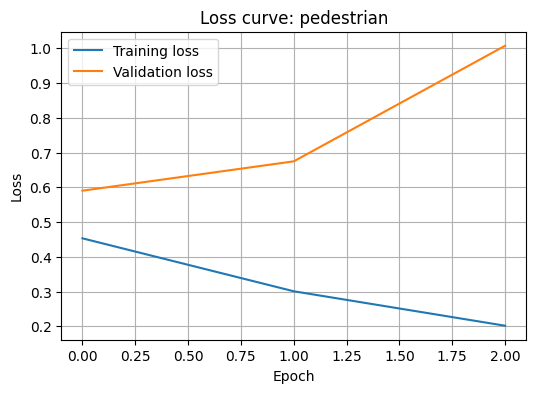

Saved: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/pedestrian_loss_curve.png


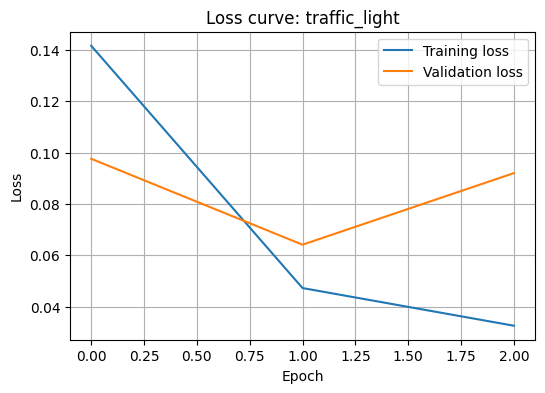

Saved: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/traffic_light_loss_curve.png


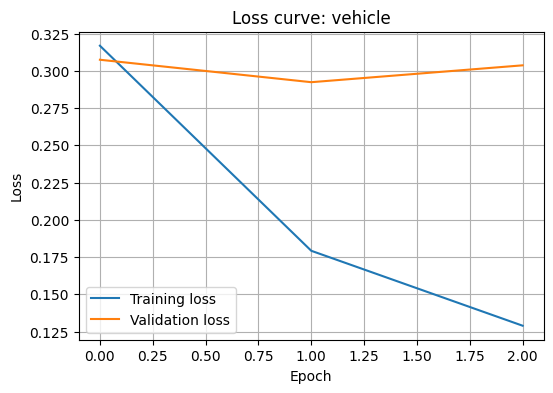

Saved: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/vehicle_loss_curve.png


In [13]:
#Plot training and validation loss curves
for task_name, history in histories.items():
    plt.figure(figsize=(6, 4))

    plt.plot(history["train_losses"], label="Training loss")
    plt.plot(history["val_losses"], label="Validation loss")

    plt.title(f"Loss curve: {task_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    save_path = RESULTS_DIR / f"{task_name}_loss_curve.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)